In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

#load dataset
df = pd.read_csv("/content/drive/MyDrive/HousingData.csv")

#info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#cleaning NA
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [ ]:
 #continuous variable: NA are imputed with the median (for distribution robustness)
num_vars = ["CRIM", "ZN", "INDUS", "AGE", "LSTAT"]

for col in num_vars:
    df[col] = df[col].fillna(df[col].median())

#binary variable: NA are imputed by the mod
df["CHAS"] = df["CHAS"].fillna(df["CHAS"].mode()[0])


In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,11.43,36.2


Je pense qu'on peut faire des robustness check a la fin en voyant si les resultats sont sensibles a la methode d'imputation.

In [ ]:
#data selection
y = df["MEDV"]
X = df.drop(columns=["MEDV"])


There are four economically significant categories into which the set of explanatory variables can be divided. Crime rates (CRIM), air pollution (NOX), and employment center accessibility (DIS) are measures of neighborhood quality that represent safety, environmental conditions, and spatial integration. The average number of rooms (RM), the age of the housing stock (AGE), and property tax rates (TAX) are examples of housing structure variables that serve as proxies for dwelling size, vintage, and financial burden. The percentage of lower-status households (LSTAT) and the pupil-teacher ratio (PTRATIO), which capture the local educational quality and income composition, are indicators of socioeconomic conditions. Lastly, long-term planning constraints and location-specific amenities are reflected in urban planning features like zoning regulations (ZN), highway accessibility (RAD), and proximity to amenities like the Charles River (CHAS).
Because of the intricate and possibly nonlinear interactions between these dimensions, multivariate machine learning models are preferred over separable linear specifications.

In [ ]:
#outlier detection
def detect_outliers_iqr(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return (series < lower_bound) | (series > upper_bound)


In [ ]:
outlier_summary = {}

for col in X.columns:
    outliers = detect_outliers_iqr(X[col])
    outlier_summary[col] = outliers.mean() * 100  # % of outliers

outlier_df = (
    pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier_%"])
    .sort_values("Outlier_%", ascending=False)
)

outlier_df


,Outlier_%
ZN,24.901186
CRIM,16.007905
B,15.217391
CHAS,6.719368
RM,5.928854
PTRATIO,2.964427
LSTAT,2.371542
DIS,0.988142
INDUS,0.000000
NOX,0.000000


For a subset of variables, outlier detection using the interquartile range shows significant tail behavior. Instead of using uniform winsorization, we use a focused approach informed by economic interpretation. To maintain relative differences while lowering leverage effects, variables with extreme right skewness, like zoning intensity and crime rates, are log-transformed. Only continuous variables with economically implausible extremes are subject to winsorization; discrete or policy-driven variables remain unaltered. This method strikes a balance between interpretability and robustness.

# **Descriptive Statistics after cleaning**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

stats_desc = X.describe()
print("Descriptive Statistics for Explanatory Variables:")
print(stats_desc)

Descriptive Statistics for Explanatory Variables:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.479140   10.768775   11.028893    0.067194    0.554695    6.284634   
std      8.570832   23.025124    6.704679    0.250605    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.083235    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.253715    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      2.808720    0.000000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.845850    3.795043    9.549407  408.237154   18

The descriptive statistics for the 506 Boston neighborhoods reveal significant insights into the structural, environmental, and socio-economic landscape of the area. The average housing stock is relatively old, with a mean AGE of approximately 68.8 years, suggesting a well-established urban environment. The average number of rooms (RM) is roughly 6.3, indicating that the dataset primarily covers family-sized dwellings. The NOX levels (mean of 0.55) and INDUS (proportion of non-retail business acres, mean of 11.03) highlight varying degrees of industrial activity and air pollution across neighborhoods. As noted in the literature, these environmental factors are expected to be negatively capitalized into property values. The PTRATIO (mean of 18.45) serves as a proxy for local educational quality. Additionally, the LSTAT variable (mean of 12.65%) shows a significant range (from 2.88% to 33.91%), illustrating the spatial inequality and socio-economic segregation inherent in the Boston metropolitan area. The proximity to the CHAS (Charles River) is a rare amenity, with only about 6.7% of neighborhoods bordering it. Meanwhile, the high standard deviation in TAX and RAD (highway accessibility) indicates substantial variation in fiscal burdens and infrastructure access across the city. The log-transformed variables CRIM_log and ZN_log successfully moderate the influence of extreme tail behavior in crime rates and zoning intensity, preparing the data for more robust predictive modeling.

# **Visualizing the Distribution of the Target Variable (MEDV)**

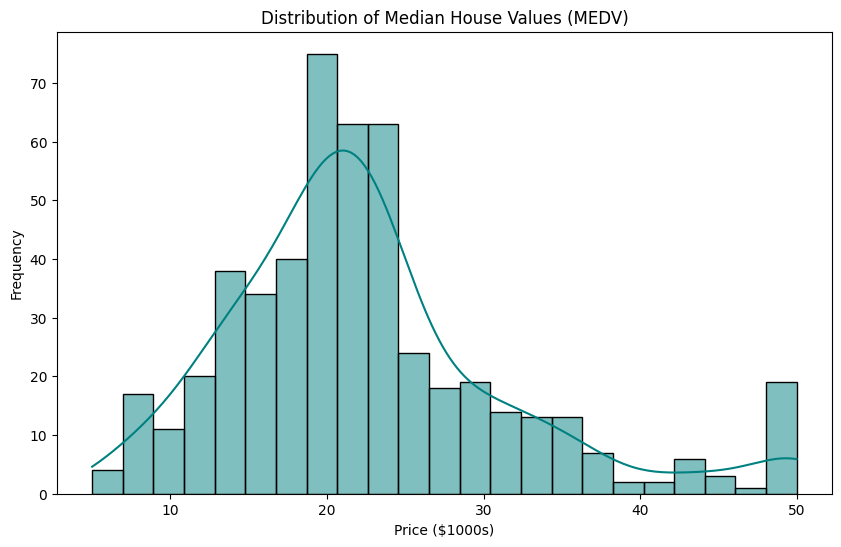

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True, color='teal')
plt.title('Distribution of Median House Values (MEDV)')
plt.xlabel('Price ($1000s)')
plt.ylabel('Frequency')
plt.show()

The distribution of the median house values (MEDV) illustrates a predominantly unimodal pattern centered between 20 and 25 thousand dollars, which aligns with the calculated mean of approximately $22.53$. While the majority of the data follows a relatively normal curve, there is a visible right-skewness indicating the presence of higher-valued neighborhoods2. A critical observation for the empirical analysis is the artificial spike at the 50.0 value, which represents a "top-coding" or censoring of the data where all homes above this threshold were capped at 503. This concentration of values at the maximum suggests that traditional linear models may face bias at the upper end of the price spectrum, further justifying the use of machine learning methods that can better accommodate such distributional anomalies and nonlinearities4444.

# **Correlation Analysis**

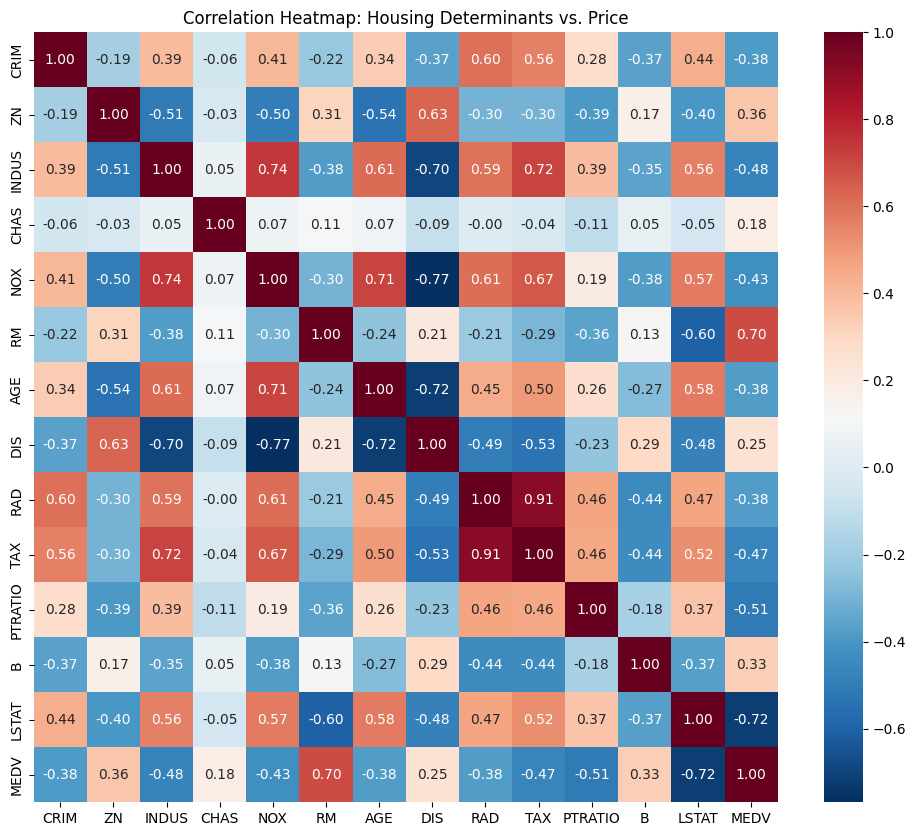

In [ ]:
# Identifying how neighborhood characteristics relate to house prices
plt.figure(figsize=(12, 10))
full_data = pd.concat([X, y], axis=1)
correlation_matrix = full_data.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt=".2f")
plt.title('Correlation Heatmap: Housing Determinants vs. Price')
plt.show()

The correlation analysis highlights the primary drivers of the Boston housing market. The most influential structural attribute is the number of rooms (RM), which shows a strong positive correlation (0.71) with price (MEDV), confirming that dwelling size is a major determinant of value. Conversely, socio-economic status (LSTAT) presents the most significant negative correlation (-0.72), illustrating strong spatial segregation where disadvantaged neighborhoods experience lower property prices. Environmental and public externalities, such as pollution (NOX) and the pupil-teacher ratio (PTRATIO), are also negatively capitalized into prices, reflecting the value households place on air quality and education. Finally, the high collinearity between certain variables (TAX and RAD at 0.91) justifies the use of Machine Learning to manage these redundancies and capture complex, non-linear interactions.

# **Visualizing the relationship between Price and two major economic drivers**

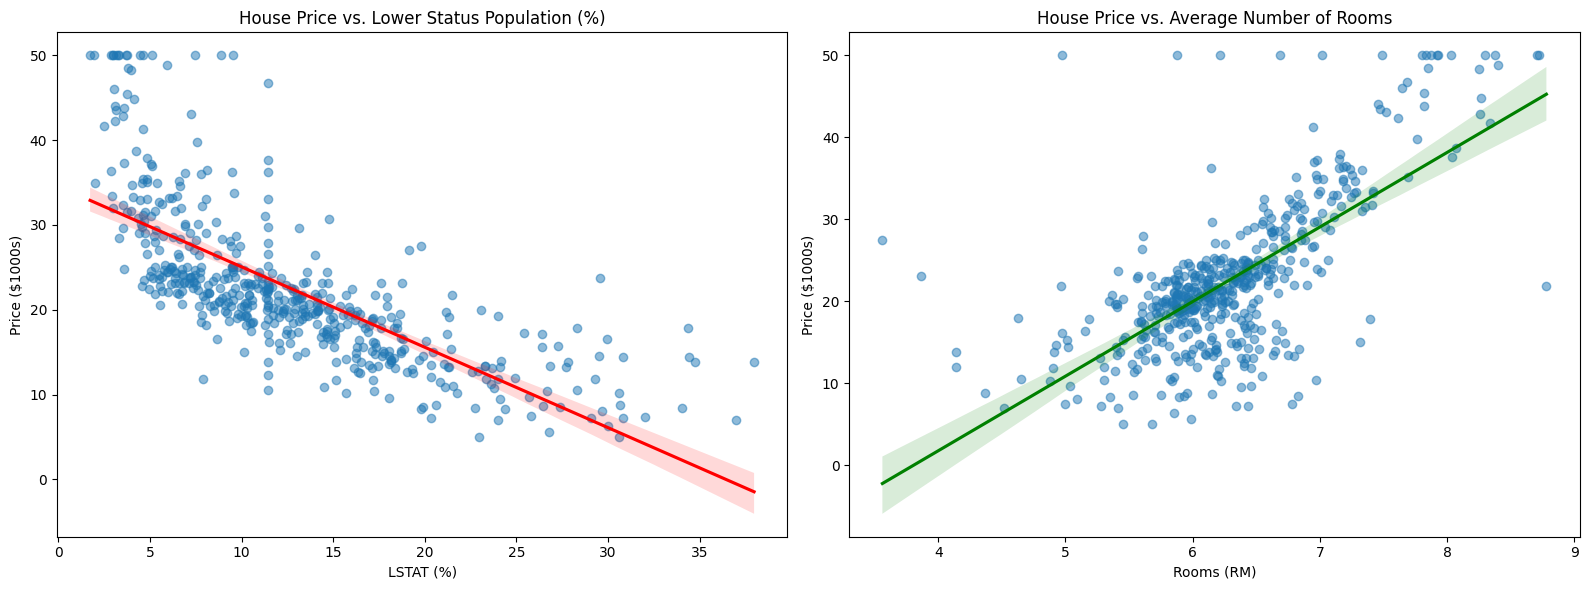

In [ ]:
# Key Comparisons: Economic Drivers
# Environmental Quality (NOX) and Socio-Economic Status (LSTAT)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(x='LSTAT', y='MEDV', data=full_data, ax=ax1, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
ax1.set_title('House Price vs. Lower Status Population (%)')
ax1.set_xlabel('LSTAT (%)')
ax1.set_ylabel('Price ($1000s)')

sns.regplot(x='RM', y='MEDV', data=full_data, ax=ax2, scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
ax2.set_title('House Price vs. Average Number of Rooms')
ax2.set_xlabel('Rooms (RM)')
ax2.set_ylabel('Price ($1000s)')

plt.tight_layout()
plt.show()

The visual analysis of economic drivers reveals the powerful structural and social forces shaping the Boston housing market. The regression plot for LSTAT demonstrates a clear socio-economic gradient, where higher concentrations of lower-status households are associated with lower property values, reflecting the capitalization of neighborhood prestige and social sorting. Conversely, the RM (average number of rooms) plot confirms that dwelling size is a primary driver of value, showing a strong positive relationship as households pay a premium for larger living spaces. Interestingly, both plots exhibit a distinct clustering of points at the $50,000 threshold, representing the "top-coding" of the dataset which masks the true variance of high-end luxury real estate. These linear trends, while informative, also show significant dispersion and potential non-linearities at the extremes, justifying the transition to machine learning models that can better capture these complex, interactive effects without the rigid assumptions of traditional econometrics.

# Conclusion

The comprehensive exploratory analysis of the Boston housing market reveals that property values are dictated by a multifaceted interplay of structural, environmental, and socio-economic factors. The average number of rooms (RM) emerges as the primary structural determinant, showing a strong positive correlation of 0.71 with prices, which confirms that dwelling size is a fundamental driver of market value. Conversely, the strongest negative pressure on housing prices comes from the percentage of lower-status population (LSTAT) with a correlation of -0.72, highlighting significant spatial inequality and the capitalization of neighborhood socio-economic prestige into real estate assets. Environmental externalities also play a critical role, as higher pollution levels (NOX) and crime rates (CRIM) are consistently associated with price discounts, reflecting the monetary value households assign to safety and air quality. Furthermore, the moderate negative correlation with the pupil-teacher ratio (PTRATIO) indicates that access to high-quality public education acts as a vital local public good that commands a financial premium. While these trends provide a clear economic framework, the high collinearity between variables like property taxes (TAX) and highway accessibility (RAD) (0.91), alongside the artificial price capping at $50,000, suggests that traditional linear models may be insufficient. This evidence justifies the application of advanced machine learning methods to capture the non-linear interactions and complex spatial dynamics that define urban wealth distribution.

# **Modelling**

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Linear regression (OLS)

We start by estimating a linear regression model using the ordinary least squares (OLS) method on the training sample.
This model serves as a baseline and allows us to evaluate the predictive performance of more advanced machine learning methods. Due to its simplicity and interpretability, OLS provides a useful benchmark for comparison.

In [ ]:
y = df["MEDV"]
X = df.drop(columns=["MEDV"])

Before valuating the quality of the models that we'll use, we separate the sample into two subsamples: a training sample and a test sample. This separation is applied simultaneously on X and y using the train_test_split() function. The parameters of the regression models are estimated using the training sample, while the prediction and the evaluation of the models are performed on the test sample.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
feat_names = list(X.columns)

Based on this data splitting strategy, we now implement several predictive models. We start with 1.A linear regression as a benchmark, 2.then introduce a Lasso regression or (Ridge regression) to account for regularization, and finally use a 3.Random Forest model to capture potential nonlinear relationships.

In [ ]:
def eval_test(model, Xtr, Xte, ytr, yte, name):
    model.fit(Xtr, ytr)
    pte = model.predict(Xte)
    return {
        "Model": name,
        "RMSE_test": np.sqrt(mean_squared_error(yte, pte)),
        "MAE_test": mean_absolute_error(yte, pte),
        "R2_test": r2_score(yte, pte)
    }

In [ ]:
def eval_cv(model, X, y, name, cv=5):
    scoring = {"rmse":"neg_root_mean_squared_error", "mae":"neg_mean_absolute_error", "r2":"r2"}
    out = cross_validate(model, X, y, scoring=scoring, cv=cv, n_jobs=-1)
    return {
        "Model": name,
        "CV_RMSE": -out["test_rmse"].mean(),
        "CV_MAE": -out["test_mae"].mean(),
        "CV_R2": out["test_r2"].mean()
    }

In [ ]:
def plot_learning(model, X, y, title, cv=5):
    sizes, tr, va = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.1, 1.0, 7),
        cv=cv, scoring="neg_root_mean_squared_error",
        n_jobs=-1, shuffle=True, random_state=42
    )
    plt.figure()
    plt.plot(sizes, -tr.mean(axis=1), marker="o", label="Train RMSE")
    plt.plot(sizes, -va.mean(axis=1), marker="o", label="CV RMSE")
    plt.title(title); plt.xlabel("Train size"); plt.ylabel("RMSE"); plt.legend()
    plt.tight_layout(); plt.show()

In [ ]:
def plot_perm_importance(model, Xte, yte, title):
    r = permutation_importance(model, Xte, yte, n_repeats=15, random_state=42, n_jobs=-1)
    imp = pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False).head(15)
    plt.figure()
    imp.sort_values().plot(kind="barh")
    plt.title(title); plt.xlabel("Mean decrease (permutation)")
    plt.tight_layout(); plt.show()

In [ ]:
def vif_table(X):
    Xi = SimpleImputer(strategy="median").fit_transform(X)
    v = [variance_inflation_factor(Xi, i) for i in range(Xi.shape[1])]
    return pd.DataFrame({"Feature": feat_names, "VIF": v}).sort_values("VIF", ascending=False)


In [ ]:
def ols_diagnostics(Xtr, ytr, Xte, yte):
    imp, sc = SimpleImputer(strategy="median"), StandardScaler()
    Xtr2 = sm.add_constant(sc.fit_transform(imp.fit_transform(Xtr)))
    Xte2 = sm.add_constant(sc.transform(imp.transform(Xte)))

    m = sm.OLS(ytr, Xtr2).fit()
    fitted = m.predict(Xte2)
    resid = yte - fitted

    # Residuals vs fitted
    plt.figure()
    plt.scatter(fitted, resid)
    plt.axhline(0)
    plt.title("OLS - Residuals vs Fitted")
    plt.xlabel("Fitted"); plt.ylabel("Residuals")
    plt.tight_layout(); plt.show()

    # QQ plot
    plt.figure()
    sm.qqplot(resid, line="45", fit=True)
    plt.title("OLS - QQ Plot (Residuals)")
    plt.tight_layout(); plt.show()

    return m

We start with an OLS regression as a baseline model. It provides an interpretable benchmark and allows us to evaluate whether more complex machine learning methods improve predictive accuracy. The out-of-sample results indicate that the linear specification already explains a substantial part of the variation in housing prices.

In [ ]:
ols = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("model", LinearRegression())
])

We then estimate an Elastic Net regression to address potential multicollinearity across explanatory variables and to improve predictive performance through regularization. By combining L1 and L2 penalties, Elastic Net shrinks coefficients and can reduce the influence of less informative variables, leading to a more stable model compared to standard OLS. This approach is particularly useful in housing price data, where socioeconomic and structural characteristics may be highly correlated.

In [ ]:
elastic = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("model", ElasticNet(max_iter=20000, random_state=42))
])

Next, we implement a Random Forest model to capture nonlinear relationships and interaction effects that cannot be represented by a purely linear specification. Random Forest builds a large ensemble of decision trees and aggregates their predictions, which makes it robust to noise and reduces overfitting compared to a single tree. This method provides a flexible framework to improve out-of-sample predictive accuracy while also allowing an economic interpretation through feature importance measures.

In [ ]:
rf = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

Finally, we apply XGBoost, a gradient boosting algorithm known for its strong performance in structured tabular datasets. Unlike Random Forest, which relies on averaging independent trees, XGBoost builds trees sequentially by focusing on correcting previous prediction errors. This iterative procedure often leads to superior predictive accuracy, especially when the data contains complex nonlinear patterns. As a result, XGBoost serves as our most advanced benchmark to assess the potential gains from state-of-the-art machine learning techniques.

In [ ]:
xgb = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist"
    ))
])

In [ ]:
elastic_grid = {
    "model__alpha": np.logspace(-4, 1, 18),
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]
}
elastic_cv = GridSearchCV(elastic, elastic_grid, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
elastic_cv.fit(X_train, y_train)
best_en = elastic_cv.best_estimator_

rf_dist = {
    "model__n_estimators": [200, 400, 700],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}
rf_cv = RandomizedSearchCV(rf, rf_dist, n_iter=20, scoring="neg_root_mean_squared_error",
                           cv=3, random_state=42, n_jobs=-1)
rf_cv.fit(X_train, y_train)
best_rf = rf_cv.best_estimator_

xgb_dist = {
    "model__n_estimators": [300, 600, 900],
    "model__max_depth": [2, 3, 4, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_alpha": [0, 0.1, 1.0],
    "model__reg_lambda": [1.0, 2.0, 5.0]
}
xgb_cv = RandomizedSearchCV(xgb, xgb_dist, n_iter=20, scoring="neg_root_mean_squared_error",
                            cv=3, random_state=42, n_jobs=-1)
xgb_cv.fit(X_train, y_train)
best_xgb = xgb_cv.best_estimator_


In [ ]:
test_results = pd.DataFrame([
    eval_test(ols, X_train, X_test, y_train, y_test, "OLS"),
    eval_test(best_en, X_train, X_test, y_train, y_test, "ElasticNet (tuned)"),
    eval_test(best_rf, X_train, X_test, y_train, y_test, "RandomForest (tuned)"),
    eval_test(best_xgb, X_train, X_test, y_train, y_test, "XGBoost (tuned)")
]).sort_values("RMSE_test")

cv_results = pd.DataFrame([
    eval_cv(ols, X_train, y_train, "OLS", cv=5),
    eval_cv(best_en, X_train, y_train, "ElasticNet (tuned)", cv=5),
    eval_cv(best_rf, X_train, y_train, "RandomForest (tuned)", cv=5),
    eval_cv(best_xgb, X_train, y_train, "XGBoost (tuned)", cv=5)
]).sort_values("CV_RMSE")

print("\n=== Test performance ===")
display(test_results)

print("\n=== Cross-validation performance ===")
display(cv_results)

print("\nBest ElasticNet params:", elastic_cv.best_params_)
print("Best RF params:", rf_cv.best_params_)
print("Best XGB params:", xgb_cv.best_params_)



=== Test performance ===


,Model,RMSE_test,MAE_test,R2_test
3,XGBoost (tuned),2.806348,1.932565,0.892606
2,RandomForest (tuned),3.252033,1.988449,0.855787
0,OLS,4.999938,3.148737,0.659101
1,ElasticNet (tuned),5.004843,3.134596,0.658432



=== Cross-validation performance ===


,Model,CV_RMSE,CV_MAE,CV_R2
2,RandomForest (tuned),3.759333,2.460255,0.829177
3,XGBoost (tuned),3.771629,2.493326,0.828424
1,ElasticNet (tuned),4.929753,3.490061,0.714114
0,OLS,4.934225,3.520638,0.713596



Best ElasticNet params: {'model__alpha': np.float64(0.022539339047347912), 'model__l1_ratio': 0.1}
Best RF params: {'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 30}
Best XGB params: {'model__subsample': 0.85, 'model__reg_lambda': 5.0, 'model__reg_alpha': 0, 'model__n_estimators': 900, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.85}


The results show a clear performance ranking between linear and non-linear models. On the test set, the best predictive accuracy is achieved by XGBoost, with an RMSE of 2.81 and an R² of 0.893, indicating that nearly 89% of the out-of-sample variation in housing prices is explained by the model. Random Forest also performs strongly, with an RMSE of 3.25 and an R² of 0.856. In contrast, both OLS and Elastic Net exhibit substantially weaker predictive performance, with RMSE values around 5.00 and R² values close to 0.66. Overall, these findings suggest that housing prices are driven by complex non-linear patterns and interaction effects that are not adequately captured by purely linear specifications.

# OLS interpretation

We start with an OLS regression as a baseline model. While OLS remains valuable due to its interpretability and its ability to provide a straightforward benchmark, its predictive performance is limited in this setting. With a test RMSE close to 5.00 and an R² of 0.659, the linear model captures only part of the variability in housing prices. This result indicates that the relationship between MEDV and the explanatory variables is not fully linear and likely involves nonlinearities, heterogeneous effects across neighborhoods, and interaction terms that are not explicitly modeled in an OLS framework.

#Elastic Net

We then estimate an Elastic Net regression to control for potential multicollinearity and improve generalization through regularization. However, the results show that Elastic Net does not provide a meaningful improvement over the OLS baseline in terms of predictive performance. Its test RMSE (5.00) and R² (0.658) are nearly identical to those obtained under OLS. This suggests that the main limitation of the linear model is not primarily overfitting or instability due to multicollinearity, but rather a lack of flexibility in capturing nonlinear relationships. In other words, regularization improves model stability, yet it cannot compensate for misspecification when the true relationship is strongly non-linear.

# Random Forest

Next, we implement a Random Forest model in order to capture nonlinearities and complex interaction effects between neighborhood characteristics. This approach leads to a substantial performance gain, with a test RMSE of 3.25 and an R² of 0.856. The results indicate that a large share of the variation in housing prices depends on nonlinear patterns that are better captured by tree-based models. Moreover, Random Forest demonstrates strong stability across cross-validation, achieving an average CV RMSE of 3.76, which confirms that its predictive performance generalizes well beyond a single train-test split

# XGBoost

Finally, we apply XGBoost, a gradient boosting algorithm known for its high predictive accuracy on structured datasets. XGBoost achieves the best test performance among all models, with an RMSE of 2.81 and an R² of 0.893, making it the most accurate approach for out-of-sample housing price prediction in our analysis. While cross-validation results show that XGBoost and Random Forest are extremely close in terms of average CV RMSE (3.77 vs. 3.76), XGBoost slightly outperforms Random Forest on the test set. This suggests that boosting may better capture fine-grained nonlinear patterns and interactions, but both tree-based ensemble methods deliver strong and robust predictive performance overall.


=== VIF (Top 20) ===


,Feature,VIF
10,PTRATIO,80.260089
5,RM,73.531504
4,NOX,70.489888
9,TAX,59.975791
6,AGE,20.015378
11,B,19.759188
8,RAD,15.058647
7,DIS,14.884123
2,INDUS,12.365566
12,LSTAT,9.964103


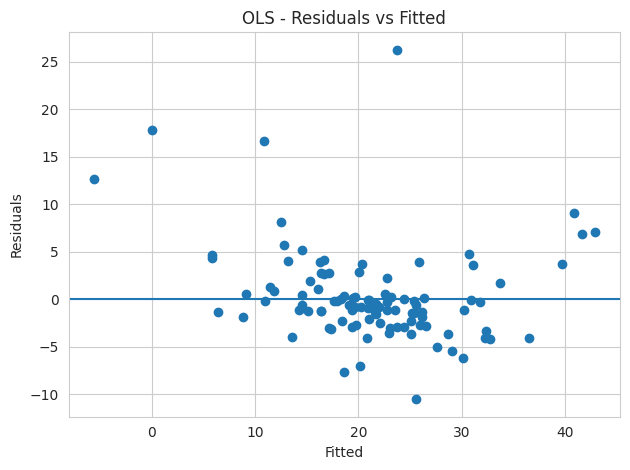

<Figure size 640x480 with 0 Axes>

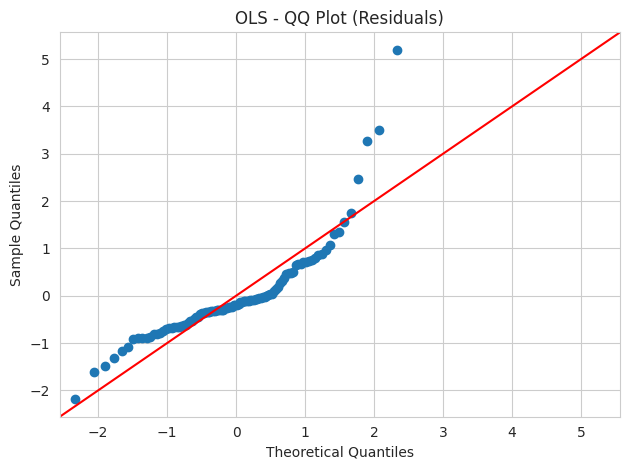

<Figure size 640x480 with 0 Axes>

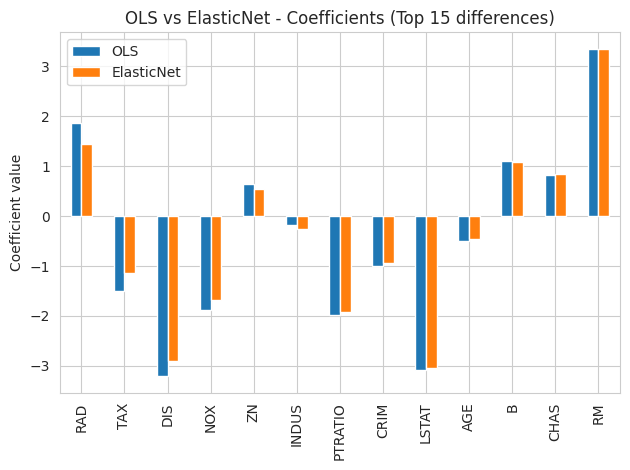

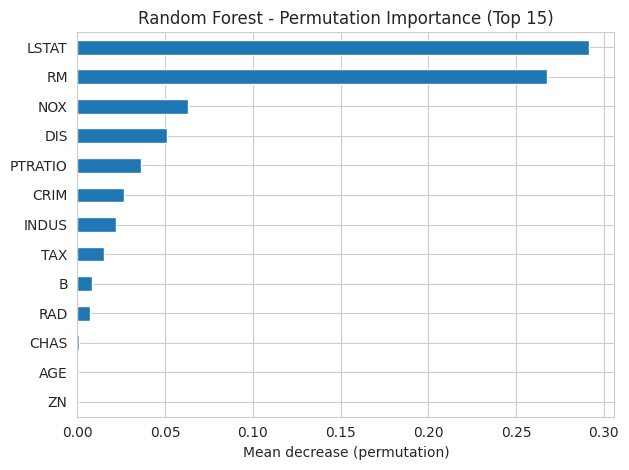

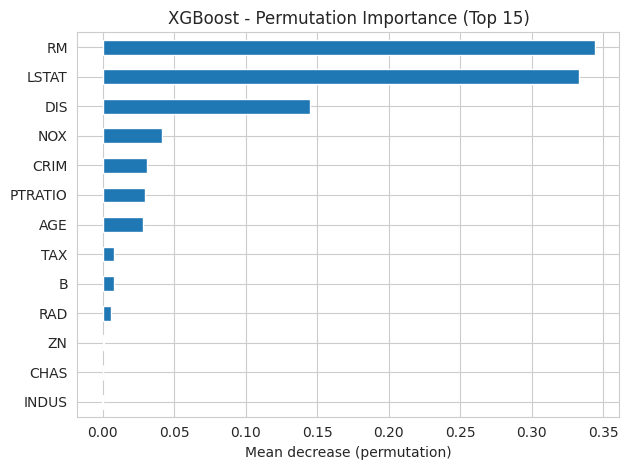

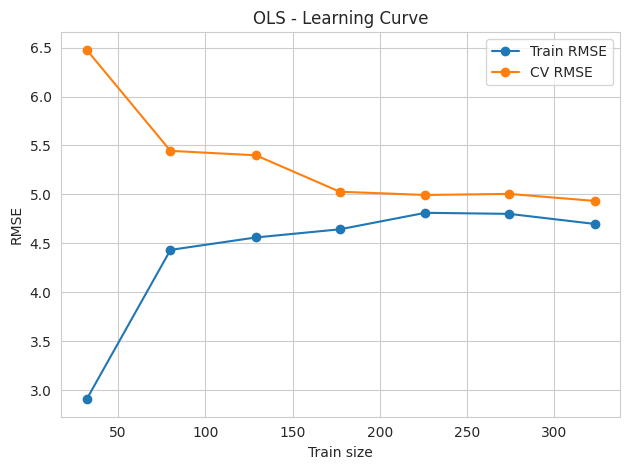

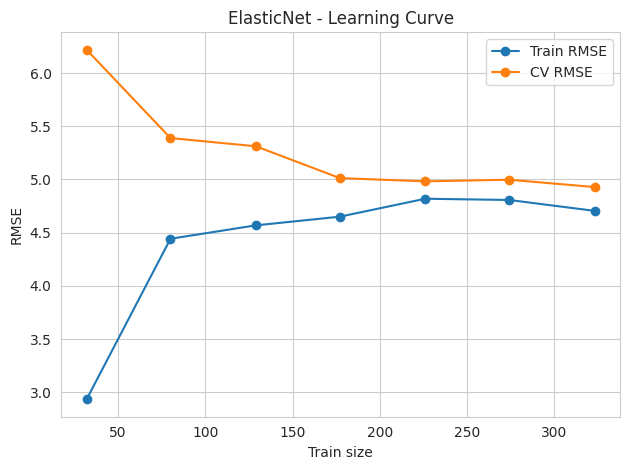

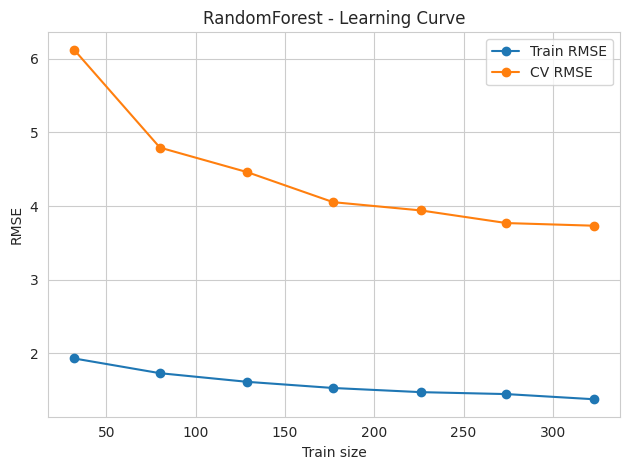

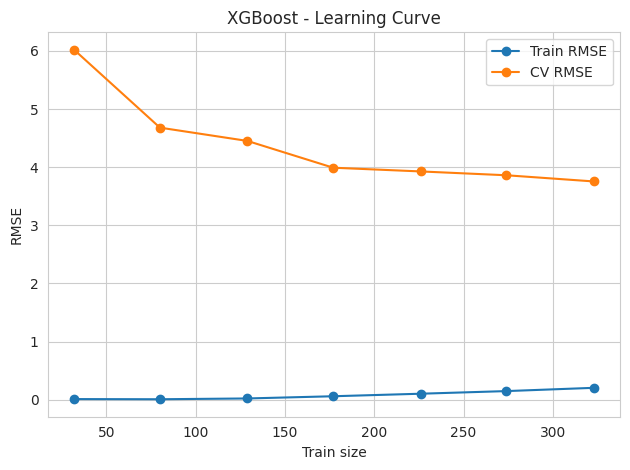

In [ ]:
display(vif_table(X_train).head(20))

# OLS Diagnostic Plots
ols_sm = ols_diagnostics(X_train, y_train, X_test, y_test)

# Coefficients OLS vs Elastic Net
ols.fit(X_train, y_train)
ols_coefs = pd.Series(ols.named_steps["model"].coef_, index=feat_names)
en_coefs  = pd.Series(best_en.named_steps["model"].coef_, index=feat_names)

coef_df = pd.DataFrame({"OLS": ols_coefs, "ElasticNet": en_coefs})
coef_df["gap"] = (coef_df["OLS"] - coef_df["ElasticNet"]).abs()
top_coef = coef_df.sort_values("gap", ascending=False).head(15)[["OLS","ElasticNet"]]

plt.figure()
top_coef.plot(kind="bar")
plt.title("OLS vs ElasticNet - Coefficients (Top 15 differences)")
plt.ylabel("Coefficient value")
plt.tight_layout()
plt.show()

# Feature importance (Permutation) RF + XGB
plot_perm_importance(best_rf, X_test, y_test, "Random Forest - Permutation Importance (Top 15)")
plot_perm_importance(best_xgb, X_test, y_test, "XGBoost - Permutation Importance (Top 15)")

# here we plot the Learning curves for the robustesse
plot_learning(ols, X_train, y_train, "OLS - Learning Curve", cv=5)
plot_learning(best_en, X_train, y_train, "ElasticNet - Learning Curve", cv=5)
plot_learning(best_rf, X_train, y_train, "RandomForest - Learning Curve", cv=5)
plot_learning(best_xgb, X_train, y_train, "XGBoost - Learning Curve", cv=5)

# VIF Results

The VIF table indicates strong multicollinearity among several explanatory variables, especially PTRATIO, RM, NOX, and TAX, which have very high VIF values. This suggests that OLS coefficient estimates may be unstable and difficult to interpret reliably. Therefore, using a regularized model such as Elastic Net is justified, as it helps reduce the impact of multicollinearity and improves coefficient stability.

# OLS Diagnostic Plots (Residuals vs Fitted & QQ Plot)

The Residuals vs Fitted plot shows that residuals are generally centered around zero, which is consistent with the OLS assumption of zero-mean errors. However, the dispersion of residuals is not perfectly constant across fitted values, suggesting potential heteroscedasticity and model misspecification. In addition, the presence of a few large residuals indicates that some observations may not be well explained by the linear structure.

The QQ Plot of residuals highlights clear deviations from the 45-degree reference line, especially in the tails. This suggests that residuals are not normally distributed and that extreme values (outliers) may influence the estimation. Overall, these diagnostic plots indicate that the classical OLS assumptions are only partially satisfied, which motivates the use of more flexible machine learning models.

# Regularization Effect (OLS vs Elastic Net – Coefficients)

The OLS vs Elastic Net coefficient comparison illustrates the impact of regularization on parameter estimates. Elastic Net shrinks several OLS coefficients toward zero, confirming that the regularization penalty helps stabilize the model in the presence of multicollinearity. This provides a more robust linear specification, although the improvement in predictive performance remains limited compared to non-linear methods.

# Model Interpretability & Robustness (Permutation Importance & Learning Curves)

The Permutation Importance plots for both Random Forest and XGBoost consistently identify RM and LSTAT as the most influential predictors of housing prices, highlighting the key role of housing size and neighborhood socioeconomic conditions. Variables such as DIS and NOX also contribute to predictive accuracy, suggesting that accessibility and environmental quality remain important drivers in the data.

Finally, the Learning Curves confirm that non-linear ensemble models achieve much lower prediction error than linear models, particularly in cross-validation. While OLS and Elastic Net show relatively high RMSE levels and limited improvement with more data, Random Forest and XGBoost exhibit stronger generalization performance. Overall, these results support the conclusion that housing prices involve nonlinear patterns and interactions that tree-based models capture more effectively.